In [1]:
!python -m pip install .. --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import ee
import geemap
import luma_ge
from luma_ge.modular_workflow import load_scheme, load_modular_training_data
from luma_ge.benchmark_pathways import PathwayBenchmark

In [3]:
# Use EE initialization from luma_ge
import ee 
import luma_ge

# Autheticate using service account (json file)

service_account_path = '../auth/ee-epstm2024.json'
success = luma_ge.initialize_with_service_account(service_account_path)

if success:
    print("Earth Engine initialized with service account successfully!")
else:
    print("Service account initialization failed. Try to authenticate earth engine manually")

#Check authentication status
status = luma_ge.get_auth_status()
print(f"Initialized: {status['initialized']}")
print(f"Authenticated: {status['authenticated']}")
if status['project']:
    print(f"Project: {status['project']}")

2026-03-29 23:47:22,357 - luma_ge.ee_config - INFO - Attempting to initialize Earth Engine with service account for project: ee-epstm2024
2026-03-29 23:47:24,822 - googleapiclient.http - WARNING - Encountered 403 Forbidden with reason "PERMISSION_DENIED"
2026-03-29 23:47:24,824 - luma_ge.ee_config - ERROR - Service account initialization failed: Caller does not have required permission to use project ee-epstm2024. Grant the caller the roles/serviceusage.serviceUsageConsumer role, or a custom role with the serviceusage.services.use permission, by visiting https://console.developers.google.com/iam-admin/iam?project=ee-epstm2024 and then retry. Propagation of the new permission may take a few minutes.
2026-03-29 23:47:24,825 - luma_ge.ee_config - INFO - Trying alternative authentication method...
2026-03-29 23:47:26,223 - luma_ge.ee_config - INFO - Earth Engine initialized with alternative method for project: ee-epstm2024


Earth Engine initialized with service account successfully!
Initialized: True
Authenticated: True
Project: projects/ee-epstm2024/assets/Reference_data_sumsel_test


In [4]:
aoi = geemap.shp_to_ee("../data/test_data/area_of_interest.shp")

In [5]:
from luma_ge.data_acquisition import Reflectance_Data, final_Image

optical_reflectance = Reflectance_Data()
composite           = final_Image()

collection, _ = optical_reflectance.get_optical_data(
    aoi, "2024-01-01", "2024-12-31", "L8_SR",
    cloud_cover=40, compute_detailed_stats=False
)

stacked_landsat = composite.get_temporal_composite(collection, aoi, reducer="median")

2026-03-29 23:47:27,125 - Reflectance_Data - INFO - ReflectanceData initialized.
2026-03-29 23:47:27,127 - final_Image - INFO - final_Image creation initialized.
2026-03-29 23:47:27,128 - Reflectance_Data - INFO - Starting data fetch for Landsat 8 Operational Land Imager Surface Reflectance
2026-03-29 23:47:27,129 - Reflectance_Data - INFO - Date range: 2024-01-01 to 2024-12-31
2026-03-29 23:47:27,129 - Reflectance_Data - INFO - Cloud cover threshold: 40%
2026-03-29 23:47:27,130 - Reflectance_Data - INFO - detailed statistics will not be computed
2026-03-29 23:47:27,131 - Reflectance_Stats - INFO - Reflectance Stats initialized.
2026-03-29 23:47:27,132 - Reflectance_Data - INFO - Filtered collection created (use compute_detailed_stats=True for more information)
2026-03-29 23:47:27,462 - final_Image - INFO - Creating median composite from 5 images
2026-03-29 23:47:27,463 - final_Image - INFO - Composite clipped to AOI
2026-03-29 23:47:28,651 - final_Image - INFO - Composite created from

In [6]:
data = load_modular_training_data(
    shp_path = "../data/test_data/training_points.shp",
    aoi      = aoi,
)

training_fc = data["ee_fc"]
print(data["columns"])   # confirm element columns are present
print(data["size"])      # confirm features loaded

['LULC_Type', 'ID', 'tree_pres', 'buil_pres', 'water_pres', 'geometry']
44


In [7]:
rules = load_scheme("../data/test_data/scheme1_threshold.csv")
rules["scheme"] = "scheme1"
print(rules)


   class_id class_name              rule  priority   scheme
0         1     Forest   tree_pres > 0.6         1  scheme1
1         2   Built Up   buil_pres > 0.6         2  scheme1
2         3      Water  water_pres > 0.9         3  scheme1


In [8]:
bench = PathwayBenchmark(
    image        = stacked_landsat,
    training_fc  = training_fc,
    rules_df     = rules,
    scheme_name  = "scheme1",
    aoi          = aoi,
    scale        = 30,       # pixel resolution in metres
    n_iterations = 300,      # MC iterations — adjust to test scalability
    n_trees      = 50,       # RF trees — same for both pathways
)

report = bench.run_all()

2026-03-29 23:47:29,263 - PathwayBenchmark - INFO - --- Pathway A: Primitive Layer + Monte Carlo ---
2026-03-29 23:47:29,264 - PathwayBenchmark - INFO - A1: Training probabilistic primitive layers on GEE...
2026-03-29 23:47:29,506 - PrimitiveLayerTrainer - INFO - Detected primitives: ['buil_pres', 'tree_pres', 'water_pres']
2026-03-29 23:47:29,507 - PrimitiveLayerTrainer - INFO - Training (probabilistic): buil_pres
2026-03-29 23:47:29,509 - PrimitiveLayerTrainer - INFO - Training (probabilistic): tree_pres
2026-03-29 23:47:29,512 - PrimitiveLayerTrainer - INFO - Training (probabilistic): water_pres
2026-03-29 23:47:30,017 - PathwayBenchmark - INFO - A2: Downloading primitive stack from GEE...
2026-03-29 23:47:31,184 - RuleSetClassifier - INFO -   Fetching 3 bands at 30m resolution...
2026-03-29 23:47:34,061 - RuleSetClassifier - INFO -   Downloaded: 221 x 268 px (59,228 pixels per band)
2026-03-29 23:47:34,064 - PathwayBenchmark - INFO - A3: Running 300 MC iterations locally...
2026-03

In [9]:
bench.print_report(report)


  BENCHMARK REPORT — scheme1
  Primitives : 3
  Classes    : 3
  Pixels     : 59,228  (30m resolution)
  MC iters   : 300

  Stage                                       Where  Time(s)  RAM(MB)    EECU
  ----------------------------------------------------------------
  [A_mc] A1: Train primitive RFs (probabilistic)    GEE      0.8      0.0  0.0075
  [A_mc] A2: Download primitive stack (getDownloadURL)    GEE      4.0      1.3  0.0405
  [A_mc] A3: Monte Carlo sampling loop       Python      0.8      2.6  0.0000
  [A_mc] A4: Aggregate mode map + entropy    Python      0.0      6.3  0.0000
  [B_direct] B1: Label training features by rules    GEE      2.5      0.0  0.0245
  [B_direct] B3: Classify image on GEE server    GEE      0.6      0.0  0.0058
  [B_direct] B4: Download classification result    GEE      3.2      0.8  0.0321
  ----------------------------------------------------------------
  TOTAL — Pathway A (MC)                                 5.6      6.3  0.0480
  TOTAL — Pathway

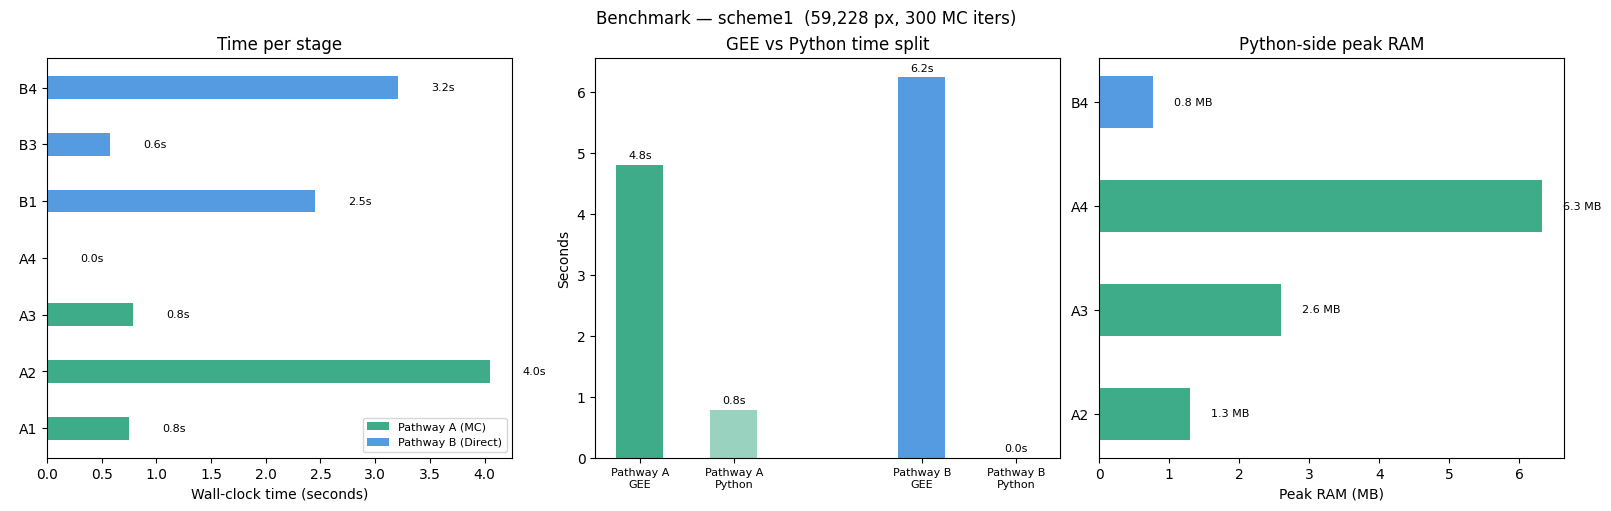

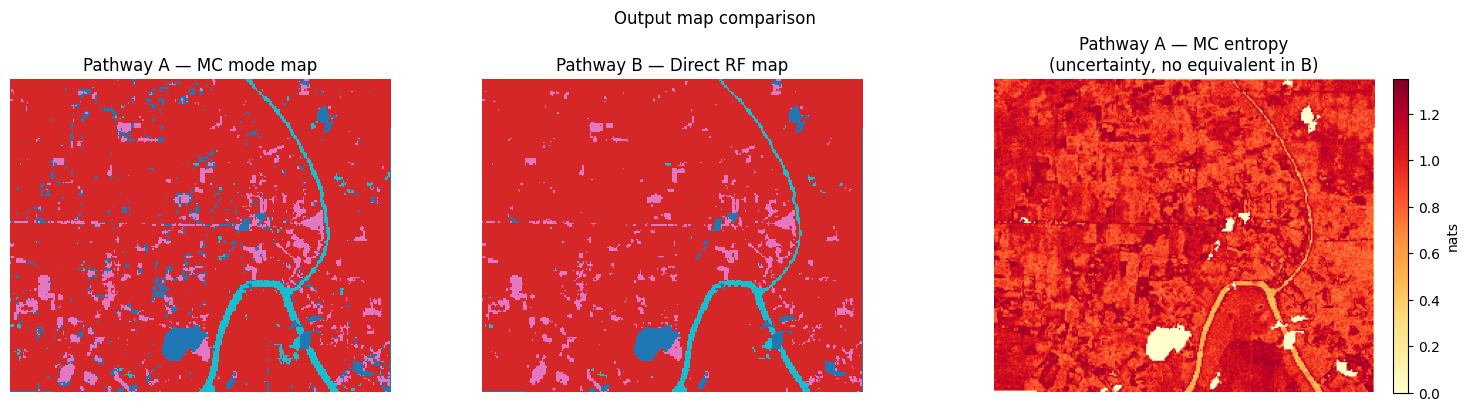

In [10]:
bench.plot_report(report)

In [11]:
# Test how MC iteration count affects time
for n_iter in [100, 200, 300, 500]:
    from luma_ge.benchmark_pathways import benchmark_pathway_a_only
    r = benchmark_pathway_a_only(
        stacked_landsat, training_fc, rules, "scheme1", aoi,
        n_iterations=n_iter
    )
    bench.print_report(r)

2026-03-29 23:47:43,346 - PathwayBenchmark - INFO - --- Pathway A: Primitive Layer + Monte Carlo ---
2026-03-29 23:47:43,347 - PathwayBenchmark - INFO - A1: Training probabilistic primitive layers on GEE...
2026-03-29 23:47:43,589 - PrimitiveLayerTrainer - INFO - Detected primitives: ['buil_pres', 'tree_pres', 'water_pres']
2026-03-29 23:47:43,591 - PrimitiveLayerTrainer - INFO - Training (probabilistic): buil_pres
2026-03-29 23:47:43,593 - PrimitiveLayerTrainer - INFO - Training (probabilistic): tree_pres
2026-03-29 23:47:43,595 - PrimitiveLayerTrainer - INFO - Training (probabilistic): water_pres
2026-03-29 23:47:43,965 - PathwayBenchmark - INFO - A2: Downloading primitive stack from GEE...
2026-03-29 23:47:44,322 - RuleSetClassifier - INFO -   Fetching 3 bands at 30m resolution...
2026-03-29 23:47:47,124 - RuleSetClassifier - INFO -   Downloaded: 221 x 268 px (59,228 pixels per band)
2026-03-29 23:47:47,129 - PathwayBenchmark - INFO - A3: Running 100 MC iterations locally...
2026-03


  BENCHMARK REPORT — scheme1
  Primitives : 3
  Classes    : 3
  Pixels     : 59,228  (30m resolution)
  MC iters   : 100

  Stage                                       Where  Time(s)  RAM(MB)    EECU
  ----------------------------------------------------------------
  [A_mc] A1: Train primitive RFs (probabilistic)    GEE      0.6      0.0  0.0062
  [A_mc] A2: Download primitive stack (getDownloadURL)    GEE      3.2      1.3  0.0316
  [A_mc] A3: Monte Carlo sampling loop       Python      0.2      2.6  0.0000
  [A_mc] A4: Aggregate mode map + entropy    Python      0.0      6.3  0.0000
  ----------------------------------------------------------------
  TOTAL — Pathway A (MC)                                 4.0      6.3  0.0378
  TOTAL — Pathway B (Direct)                             0.0      0.0  0.0000

  Only Pathway A was run — no Pathway B total to compare.




2026-03-29 23:47:48,284 - PathwayBenchmark - INFO - --- Pathway A: Primitive Layer + Monte Carlo ---
2026-03-29 23:47:48,286 - PathwayBenchmark - INFO - A1: Training probabilistic primitive layers on GEE...
2026-03-29 23:47:48,555 - PrimitiveLayerTrainer - INFO - Detected primitives: ['buil_pres', 'tree_pres', 'water_pres']
2026-03-29 23:47:48,556 - PrimitiveLayerTrainer - INFO - Training (probabilistic): buil_pres
2026-03-29 23:47:48,559 - PrimitiveLayerTrainer - INFO - Training (probabilistic): tree_pres
2026-03-29 23:47:48,561 - PrimitiveLayerTrainer - INFO - Training (probabilistic): water_pres
2026-03-29 23:47:48,881 - PathwayBenchmark - INFO - A2: Downloading primitive stack from GEE...
2026-03-29 23:47:49,172 - RuleSetClassifier - INFO -   Fetching 3 bands at 30m resolution...
2026-03-29 23:47:52,168 - RuleSetClassifier - INFO -   Downloaded: 221 x 268 px (59,228 pixels per band)
2026-03-29 23:47:52,173 - PathwayBenchmark - INFO - A3: Running 200 MC iterations locally...
2026-03


  BENCHMARK REPORT — scheme1
  Primitives : 3
  Classes    : 3
  Pixels     : 59,228  (30m resolution)
  MC iters   : 200

  Stage                                       Where  Time(s)  RAM(MB)    EECU
  ----------------------------------------------------------------
  [A_mc] A1: Train primitive RFs (probabilistic)    GEE      0.6      0.0  0.0059
  [A_mc] A2: Download primitive stack (getDownloadURL)    GEE      3.3      1.3  0.0329
  [A_mc] A3: Monte Carlo sampling loop       Python      0.5      2.6  0.0000
  [A_mc] A4: Aggregate mode map + entropy    Python      0.0      6.3  0.0000
  ----------------------------------------------------------------
  TOTAL — Pathway A (MC)                                 4.4      6.3  0.0388
  TOTAL — Pathway B (Direct)                             0.0      0.0  0.0000

  Only Pathway A was run — no Pathway B total to compare.




2026-03-29 23:47:53,010 - PathwayBenchmark - INFO - --- Pathway A: Primitive Layer + Monte Carlo ---
2026-03-29 23:47:53,011 - PathwayBenchmark - INFO - A1: Training probabilistic primitive layers on GEE...
2026-03-29 23:47:53,265 - PrimitiveLayerTrainer - INFO - Detected primitives: ['buil_pres', 'tree_pres', 'water_pres']
2026-03-29 23:47:53,266 - PrimitiveLayerTrainer - INFO - Training (probabilistic): buil_pres
2026-03-29 23:47:53,269 - PrimitiveLayerTrainer - INFO - Training (probabilistic): tree_pres
2026-03-29 23:47:53,271 - PrimitiveLayerTrainer - INFO - Training (probabilistic): water_pres
2026-03-29 23:47:54,172 - PathwayBenchmark - INFO - A2: Downloading primitive stack from GEE...
2026-03-29 23:47:55,066 - RuleSetClassifier - INFO -   Fetching 3 bands at 30m resolution...
2026-03-29 23:47:57,503 - RuleSetClassifier - INFO -   Downloaded: 221 x 268 px (59,228 pixels per band)
2026-03-29 23:47:57,508 - PathwayBenchmark - INFO - A3: Running 300 MC iterations locally...
2026-03


  BENCHMARK REPORT — scheme1
  Primitives : 3
  Classes    : 3
  Pixels     : 59,228  (30m resolution)
  MC iters   : 300

  Stage                                       Where  Time(s)  RAM(MB)    EECU
  ----------------------------------------------------------------
  [A_mc] A1: Train primitive RFs (probabilistic)    GEE      1.2      0.0  0.0116
  [A_mc] A2: Download primitive stack (getDownloadURL)    GEE      3.3      1.3  0.0334
  [A_mc] A3: Monte Carlo sampling loop       Python      0.8      2.6  0.0000
  [A_mc] A4: Aggregate mode map + entropy    Python      0.0      6.3  0.0000
  ----------------------------------------------------------------
  TOTAL — Pathway A (MC)                                 5.3      6.3  0.0450
  TOTAL — Pathway B (Direct)                             0.0      0.0  0.0000

  Only Pathway A was run — no Pathway B total to compare.




2026-03-29 23:47:58,641 - PathwayBenchmark - INFO - --- Pathway A: Primitive Layer + Monte Carlo ---
2026-03-29 23:47:58,642 - PathwayBenchmark - INFO - A1: Training probabilistic primitive layers on GEE...
2026-03-29 23:47:58,906 - PrimitiveLayerTrainer - INFO - Detected primitives: ['buil_pres', 'tree_pres', 'water_pres']
2026-03-29 23:47:58,907 - PrimitiveLayerTrainer - INFO - Training (probabilistic): buil_pres
2026-03-29 23:47:58,910 - PrimitiveLayerTrainer - INFO - Training (probabilistic): tree_pres
2026-03-29 23:47:58,911 - PrimitiveLayerTrainer - INFO - Training (probabilistic): water_pres
2026-03-29 23:47:59,285 - PathwayBenchmark - INFO - A2: Downloading primitive stack from GEE...
2026-03-29 23:47:59,674 - RuleSetClassifier - INFO -   Fetching 3 bands at 30m resolution...
2026-03-29 23:48:02,020 - RuleSetClassifier - INFO -   Downloaded: 221 x 268 px (59,228 pixels per band)
2026-03-29 23:48:02,024 - PathwayBenchmark - INFO - A3: Running 500 MC iterations locally...
2026-03


  BENCHMARK REPORT — scheme1
  Primitives : 3
  Classes    : 3
  Pixels     : 59,228  (30m resolution)
  MC iters   : 500

  Stage                                       Where  Time(s)  RAM(MB)    EECU
  ----------------------------------------------------------------
  [A_mc] A1: Train primitive RFs (probabilistic)    GEE      0.6      0.0  0.0064
  [A_mc] A2: Download primitive stack (getDownloadURL)    GEE      2.7      1.3  0.0274
  [A_mc] A3: Monte Carlo sampling loop       Python      1.4      2.6  0.0000
  [A_mc] A4: Aggregate mode map + entropy    Python      0.0      6.3  0.0000
  ----------------------------------------------------------------
  TOTAL — Pathway A (MC)                                 4.8      6.3  0.0338
  TOTAL — Pathway B (Direct)                             0.0      0.0  0.0000

  Only Pathway A was run — no Pathway B total to compare.


